In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from Bio import SeqIO
import os
from collections import Counter
import scipy
from scipy.stats import mannwhitneyu, chi2_contingency,ks_2samp,kruskal
from matplotlib.patches import Patch

plt.rcParams.update({'font.family':'Arial'})




In [33]:
base_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/code/'


fig_dir = '/Users/cdubin/Box/VMGC_cervical_dysplasia_paper/figures/'

In [34]:
species = pd.read_csv(f'{base_dir}/compare_VMGC_GTDB/select_species_for_analysis/shared_species_for_analysis.csv')
species = species.set_index('species_id_VMGC')
species_list = species.index.tolist()
species

,species,species_id_GTDB,num_samples_GTDB,num_samples_VMGC
species_id_VMGC,,,,
988598,Lactobacillus crispatus,100122,135,135
240891,Lactobacillus iners,100505,120,121
783244,Bifidobacterium vaginale,100323,78,78
619501,Fannyhessea vaginae,103895,65,43
571325,Lactobacillus jensenii,100515,35,35
611554,Lactobacillus gasseri,100460,20,20


In [35]:
genome_info = pd.read_csv(f'genomes_info_source_and_genome_type.csv')
genome_info['species_name'] = genome_info['species'].map(species['species'])

midas_ann_full = pd.read_excel(f'{base_dir}/GTDB/classify_GTDB_sources/six_species_origins.xlsx', index_col=0)
midas_ann_full['species_name'] = midas_ann_full['species'].map(species.reset_index().set_index('species_id_GTDB')['species'])
midas_ann_full = midas_ann_full.drop_duplicates('Assembly Accession')
midas_ann_full = midas_ann_full.set_index('Assembly Accession')

midas_ann_full['human_subcategory']  = midas_ann_full['human_subcategory'].replace('urine','urinary tract')
midas_ann_full['human_subcategory']  = midas_ann_full['human_subcategory'].replace('gastrointestinal','gastrointestinal tract')
midas_ann_full['human_subcategory']  = midas_ann_full['human_subcategory'].replace('female reproductive tract','FRT')


midas_genome_to_source = midas_ann_full['human_subcategory'].to_dict()

In [36]:



def fill_source(row):

    if row['genome'] in  midas_genome_to_source:

        source = midas_genome_to_source[row['genome']]
        if not pd.isna(source):
            return source

    if row['database'] in ['VMGC','shared']:
        return 'FRT'

    else:
        return 'unknown'

genome_info['source'] = genome_info.apply(fill_source, axis=1)
genome_info['source'].value_counts()
    

source
FRT                       4776
urinary tract               58
non-human                   50
gastrointestinal tract      14
unknown                     10
other                        5
respiratory                  4
oral                         2
Name: count, dtype: int64

### Extract annotation info

In [37]:
counts = []

for genome in genome_info['genome'].values:

    ### GENOMAD VIRUS
    genomad_virus = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/genomad_virus/{genome}_virus_summary.tsv'  
    df = pd.read_csv(genomad_virus, sep='\t')

    num_viral_seqs = df.shape[0]
    num_integrated_seqs = df['coordinates'].dropna().shape[0]
    num_non_integrated_seqs = df[df['coordinates'].isna()].shape[0]

    ### GENOMAD PLASMID
    genomad_plasmid = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/genomad_plasmid/{genome}_plasmid_summary.tsv'  
    df = pd.read_csv(genomad_plasmid, sep='\t')
    num_plasmids = df.shape[0]

    # ### DISINFINDER     
    disinfinder = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/DisinFinder/{genome}_DisinFinder_results_tab.txt'  
    df = pd.read_csv(disinfinder, sep='\t')
    num_disinf = df.shape[0]

    if df.shape[0] > 1:
        break

    ### RESFINDER     
    resfinder = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/ResFinder/{genome}_ResFinder_results_tab.txt'  
    df = pd.read_csv(resfinder, sep='\t')
    num_resfinder = df.shape[0]
    num_lsa = df[df['Resistance gene'] == 'lsa(C)'].shape[0]
    num_tet = df[df['Resistance gene'] == 'tet(M)'].shape[0]
    num_erm = df[df['Resistance gene'] == 'erm(B)'].shape[0]

    ### MEFINDER     
    mefinder = f'{base_dir}/compare_VMGC_GTDB/combined_db/VMGC_GTDB_combined_db/pangenome_annotation_summary_outputs/mefinder/{genome}_mefinder.csv'  
    df = pd.read_csv(mefinder, comment='#')
    num_IS = df[df['type'] == 'insertion sequence'].shape[0]
    num_transposons = df[df['type'].isin(['ice', 'composite transposon', 'unit transposon'])].shape[0]

    counts += [[genome,num_viral_seqs,num_integrated_seqs,num_non_integrated_seqs,num_plasmids,num_disinf,num_resfinder,num_lsa, num_tet, num_erm, num_IS, num_transposons]]

counts_df = pd.DataFrame(counts)
counts_df.columns = ['genome','num_viral_seqs','num_integrated_seqs','num_non_integrated_seqs','num_plasmids',
                    'num_disinf',
                    'num_resfinder','num_lsa', 'num_tet', 'num_erm','num_IS', 'num_transposons']
counts_df = counts_df.set_index('genome')

counts_df = genome_info.merge(counts_df, left_on='genome', right_index=True)
counts_df['num_ME'] = counts_df['num_IS'] + counts_df['num_transposons']


/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_74280/1249540340.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_74280/1249540340.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(new_labels, fontsize=12)
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_74280/1249540340.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/var/folders/nh/_pzp_lps21jf91jy0p779fvm0000gn/T/ipykernel_74280/1249540340.py:75: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_tic

988598 num_ME 4.0 11.0
988598 num_viral_seqs 3.0 4.0
988598 num_plasmids 13.0 23.5
240891 num_ME 0.0 1.0
240891 num_viral_seqs 0.0 1.0
240891 num_plasmids 2.0 1.0
571325 num_ME 0.0 1.5
571325 num_viral_seqs 1.0 1.0
571325 num_plasmids 3.0 2.0
611554 num_ME 1.0 2.0
611554 num_viral_seqs 1.0 2.0
611554 num_plasmids 3.0 1.0
783244 num_ME 0.0 1.0
783244 num_viral_seqs 0.0 0.0
783244 num_plasmids 0.0 0.0
619501 num_ME 0.0 0.0
619501 num_viral_seqs 0.0 0.0
619501 num_plasmids 0.0 0.0


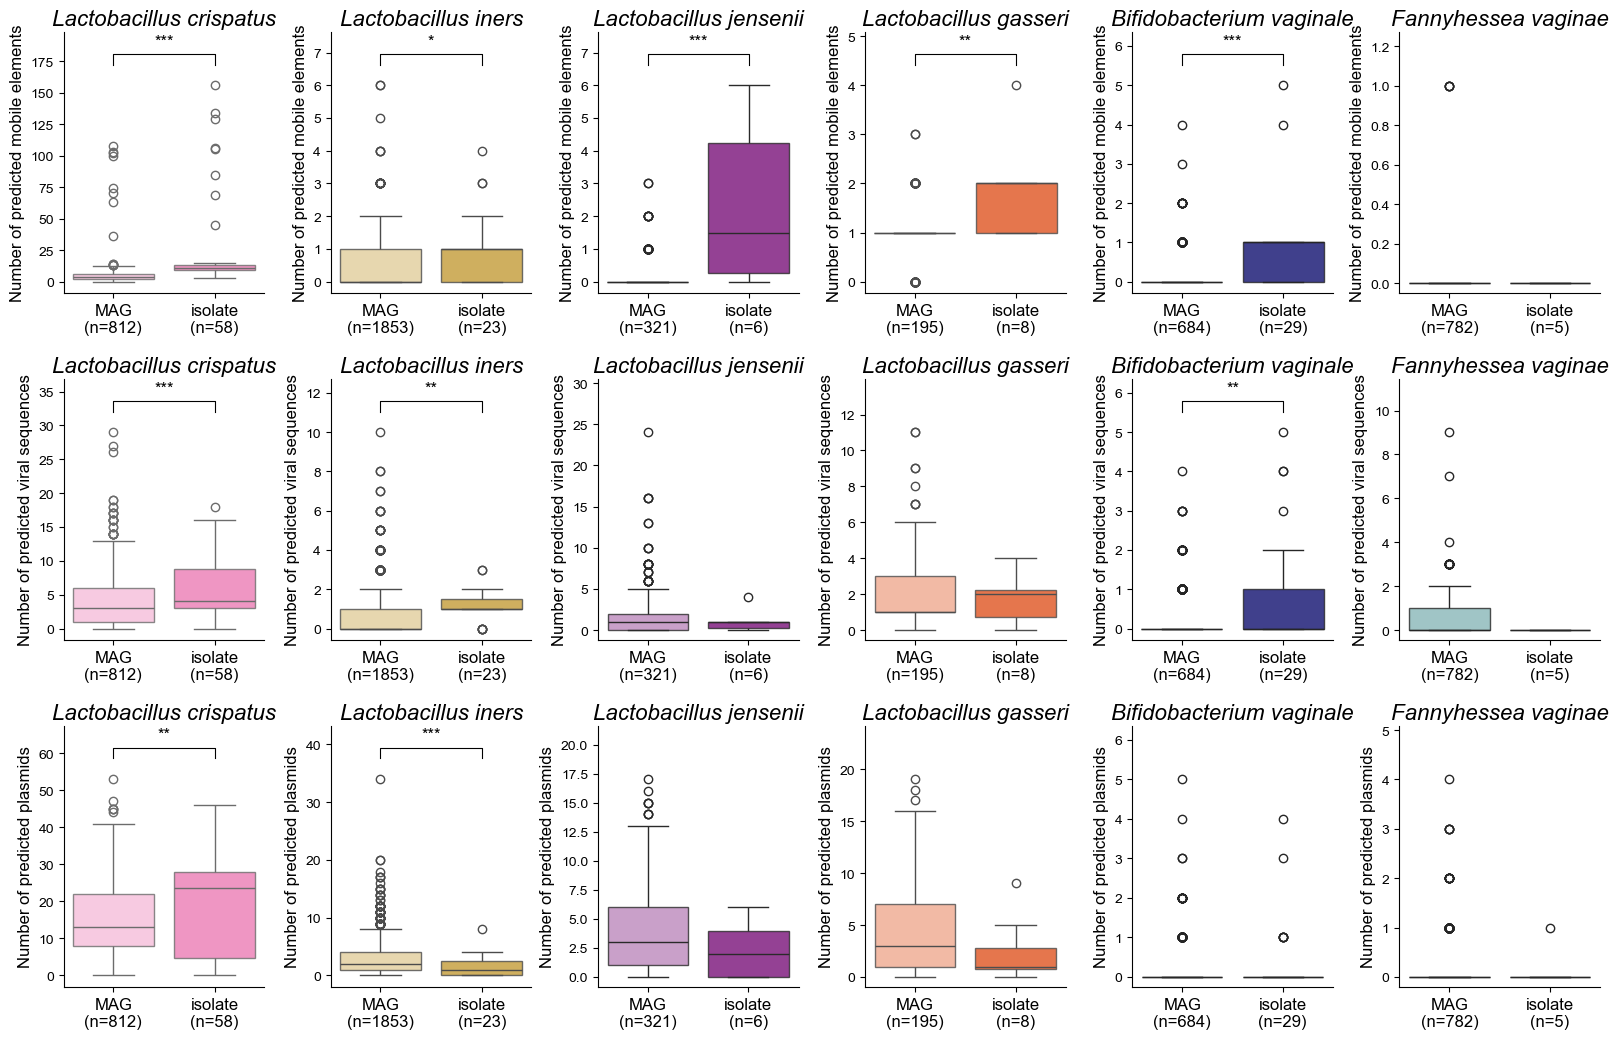

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.colors as mcolors
from scipy.stats import mannwhitneyu
import numpy as np

# --- Keep your helper functions ---
def p_to_stars(p):
    if p < 0.001: return "***"
    elif p < 0.01: return "**"
    elif p < 0.05: return "*"
    else: return "ns"

def lighten_color(color, amount=0.4):
    try:
        c = mcolors.cnames[color]
    except:
        c = color
    c = mcolors.to_rgb(c)
    return [(1 - amount) * x + amount for x in c]

# --- Parameters ---
colors = ['hotpink', 'goldenrod', 'darkmagenta', 'orangered', 'navy', 'teal']
sp_code_order = [988598, 240891, 571325, 611554, 783244, 619501]

col_names = {
    'num_viral_seqs': 'Number of predicted viral sequences',
    'num_plasmids': 'Number of predicted plasmids',
    'num_ME': 'Number of predicted mobile elements'
}
metrics = ['num_ME', 'num_viral_seqs', 'num_plasmids', ]
genome_order = ['MAG', 'isolate']

n_species = len(sp_code_order)
n_metrics = len(metrics)

# --- Flip subplots: Rows = Metrics, Cols = Species ---
fig, axes = plt.subplots(n_metrics, n_species, figsize=(2.7 * n_species, 3.5 * n_metrics))

for col_idx, sp in enumerate(sp_code_order):
    # Filter data for this species column
    frt_sp = counts_df[(counts_df['species'] == sp) & (counts_df['source'] == 'FRT')]
    
    # Define palette based on species color
    base_color = colors[col_idx]
    col_palette = {
        'MAG': lighten_color(base_color, amount=0.5),
        'isolate': base_color
    }

    # Calculate counts for labels
    counts = frt_sp['genome_type'].value_counts()
    new_labels = [f"{g}\n(n={counts.get(g, 0)})" for g in genome_order]

    for row_idx, metric in enumerate(metrics):
        ax = axes[row_idx, col_idx]

        sns.boxplot(
            x='genome_type', y=metric, data=frt_sp, order=genome_order, 
            ax=ax, palette=col_palette, boxprops=dict(alpha=0.8),
            linewidth=1.0
        )

        sns.despine(ax=ax)
        ax.set_xlabel('')
        
        # Only set Y-label for the first column (the metric name)
        # if col_idx == 0:
        ax.set_ylabel(col_names[metric], fontsize=12)
        # else:
        #     ax.set_ylabel('')

        # Only set X-axis labels (MAG/Isolate) for the bottom row
        # if row_idx == n_metrics - 1:
        ax.set_xticklabels(new_labels, fontsize=12)
        # else:
        #     ax.set_xticklabels([])

        # Set Species Name as Title for the top row only
        # if row_idx == 0:
            # Assumes 'species' dataframe is available for mapping IDs to names
        sp_name = species.loc[sp]['species'] 
        ax.set_title(sp_name, fontsize=16, pad=5, fontstyle='italic')

        # --- Stats logic ---
        vals1 = frt_sp[frt_sp['genome_type'] == 'MAG'][metric].dropna().values
        vals2 = frt_sp[frt_sp['genome_type'] == 'isolate'][metric].dropna().values

        if len(vals1) >= 3 and len(vals2) >= 3:
            stat, pval = mannwhitneyu(vals1, vals2, alternative='two-sided')

            print(sp, metric, np.median(vals1), np.median(vals2))
            label = p_to_stars(pval)

            ymin, ymax = ax.get_ylim()
            actual_max = max(frt_sp[metric].max(), ymax)
            pad = (actual_max - ymin) * 0.05
            bracket_height = actual_max + pad
            
            if label != 'ns':

                ax.plot([0, 0, 1, 1], [bracket_height, bracket_height + pad, bracket_height + pad, bracket_height],
                        color='k', linewidth=0.8)
                ax.text(0.5, bracket_height + pad * 1.5, label, ha='center', va='bottom', fontsize=12)
                ax.set_ylim(top=bracket_height + pad * 3)
            else:
                 ax.set_ylim(top=bracket_height + pad * 3)


# Final layout tweaks
fig.tight_layout(h_pad=1.5, w_pad=1.2)
plt.savefig(f'{fig_dir}/figure_S5CDE.png', dpi=300, bbox_inches='tight')
plt.show()